In [1]:
# Cell 1: Import Libraries
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.sparse import csgraph # Although csgraph is imported, it's not strictly used in this self-implemented version.

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Cell 2: Data Loading Function
def load_data(nodes_file, edges_file):
    """
    Loads node and edge data from files.
    
    Args:
        nodes_file (str): Path to the nodes.txt file.
        edges_file (str): Path to the edges.txt file.
        
    Returns:
        tuple: A tuple containing:
            - nodes_df (pd.DataFrame): DataFrame of nodes with 'id' and 'label'.
            - edges_df (pd.DataFrame): DataFrame of edges with 'source' and 'target'.
    """
    # Load nodes data: id, blog_name, label, source_type
    nodes_df = pd.read_csv(nodes_file, sep='\t', header=None, names=['id', 'blog_name', 'label', 'source_type'])
    
    # Load edges data: source_id, target_id
    edges_df = pd.read_csv(edges_file, sep='\t', header=None, names=['source', 'target'])
    
    return nodes_df, edges_df

print("load_data function defined.")

load_data function defined.


In [3]:
# Cell 3: Graph Preprocessing Function
def preprocess_graph(nodes_df, edges_df):
    """
    Preprocesses the graph data: removes isolated nodes and creates adjacency matrix.
    
    Args:
        nodes_df (pd.DataFrame): DataFrame of nodes.
        edges_df (pd.DataFrame): DataFrame of edges.
        
    Returns:
        tuple: A tuple containing:
            - adj_matrix (np.ndarray): Symmetric adjacency matrix.
            - node_labels (np.ndarray): Labels of the remaining nodes, indexed by new_id.
            - id_to_new_id (dict): Mapping from original node ID to new contiguous ID.
            - new_id_to_id (dict): Mapping from new contiguous ID to original node ID.
    """
    # Get all unique nodes involved in edges
    # Using .values ensures it's a numpy array for unique()
    connected_nodes = np.unique(np.concatenate((edges_df['source'].values, edges_df['target'].values)))
    
    # Filter nodes_df to include only connected nodes
    filtered_nodes_df = nodes_df[nodes_df['id'].isin(connected_nodes)].copy()
    
    # Create a mapping from original node IDs to new contiguous IDs (0 to N-1)
    # This is crucial because original IDs might not be contiguous or start from 0
    id_to_new_id = {old_id: new_id for new_id, old_id in enumerate(filtered_nodes_df['id'].unique())}
    new_id_to_id = {new_id: old_id for old_id, new_id in id_to_new_id.items()}
    
    num_nodes = len(id_to_new_id)
    
    # Initialize adjacency matrix with zeros
    adj_matrix = np.zeros((num_nodes, num_nodes), dtype=int)
    
    # Populate adjacency matrix
    for _, row in edges_df.iterrows():
        u_orig, v_orig = row['source'], row['target']
        
        # Only add edge if both nodes exist in the filtered set
        if u_orig in id_to_new_id and v_orig in id_to_new_id:
            u_new = id_to_new_id[u_orig]
            v_new = id_to_new_id[v_orig]
            
            # Since the graph is undirected, set both (u,v) and (v,u) to 1
            adj_matrix[u_new, v_new] = 1
            adj_matrix[v_new, u_new] = 1
            
    # Get labels for the filtered nodes, ordered by their new_id
    # Ensure labels are retrieved in the order of new_id_to_id keys
    node_labels = filtered_nodes_df.set_index('id').loc[list(new_id_to_id.values())]['label'].values
    
    return adj_matrix, node_labels, id_to_new_id, new_id_to_id

print("preprocess_graph function defined.")

preprocess_graph function defined.


In [4]:
# Cell 4: Laplacian Computation Function
def compute_laplacian(adj_matrix):
    """
    Computes the unnormalized Laplacian matrix L = D - A.
    
    Args:
        adj_matrix (np.ndarray): The adjacency matrix.
        
    Returns:
        np.ndarray: The unnormalized Laplacian matrix.
    """
    degree_matrix = np.diag(np.sum(adj_matrix, axis=1))
    laplacian_matrix = degree_matrix - adj_matrix
    return laplacian_matrix

print("compute_laplacian function defined.")

compute_laplacian function defined.


In [5]:
# Cell 5: K-Means Implementation
def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points."""
    return np.sqrt(np.sum((point1 - point2)**2))

def kmeans(data, k, max_iterations=100, tolerance=1e-4):
    """
    Performs K-Means clustering.
    
    Args:
        data (np.ndarray): The data points to cluster.
        k (int): The number of clusters.
        max_iterations (int): Maximum number of iterations for K-Means.
        tolerance (float): Convergence tolerance for centroid movement.
        
    Returns:
        np.ndarray: An array of cluster assignments for each data point.
    """
    num_samples, num_features = data.shape
    
    # 1. Initialize centroids randomly
    # Select k random data points as initial centroids
    random_indices = np.random.choice(num_samples, k, replace=False)
    centroids = data[random_indices]
    
    for iteration in range(max_iterations):
        # 2. Assign each data point to the closest centroid
        cluster_assignments = np.zeros(num_samples, dtype=int)
        for i in range(num_samples):
            distances = [euclidean_distance(data[i], centroid) for centroid in centroids]
            cluster_assignments[i] = np.argmin(distances)
            
        # 3. Update centroids based on the mean of assigned points
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            points_in_cluster = data[cluster_assignments == j]
            if len(points_in_cluster) > 0:
                new_centroids[j] = np.mean(points_in_cluster, axis=0)
            else:
                # Handle empty cluster: re-initialize centroid to a random point
                # This helps prevent issues if a cluster becomes empty
                new_centroids[j] = data[np.random.choice(num_samples)]
        
        # 4. Check for convergence
        centroid_movement = np.sum([euclidean_distance(centroids[j], new_centroids[j]) for j in range(k)])
        if centroid_movement < tolerance:
            # print(f"K-Means converged after {iteration + 1} iterations.") # Uncomment for debugging
            break
            
        centroids = new_centroids
        
    return cluster_assignments

print("kmeans and euclidean_distance functions defined.")


kmeans and euclidean_distance functions defined.


In [6]:
# Cell 6: Spectral Clustering Function
def spectral_clustering(adj_matrix, k):
    """
    Performs spectral clustering on the given adjacency matrix.
    
    Args:
        adj_matrix (np.ndarray): The adjacency matrix.
        k (int): The number of clusters.
        
    Returns:
        np.ndarray: An array of cluster assignments for each node.
    """
    laplacian = compute_laplacian(adj_matrix)
    
    # Compute eigenvalues and eigenvectors
    # 'eigh' is used for symmetric matrices, which is more stable
    eigenvalues, eigenvectors = np.linalg.eigh(laplacian)
    
    # Sort eigenvalues and corresponding eigenvectors by eigenvalue magnitude
    sorted_indices = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    
    # Select the k smallest non-zero eigenvectors
    # The first eigenvector (corresponding to eigenvalue 0) is trivial (all ones)
    # We look for eigenvalues slightly greater than zero due to numerical precision
    
    # Find indices of eigenvalues greater than a small tolerance
    non_zero_eigenvalue_indices = np.where(eigenvalues > 1e-8)[0]
    
    if len(non_zero_eigenvalue_indices) < k:
        print(f"Warning: Not enough non-zero eigenvalues for k={k}. Using all available non-zero eigenvectors.")
        selected_eigenvector_indices = non_zero_eigenvalue_indices
    else:
        # Select the first k non-zero eigenvectors
        selected_eigenvector_indices = non_zero_eigenvalue_indices[:k]
    
    # Construct the feature matrix U from the selected eigenvectors
    U = eigenvectors[:, selected_eigenvector_indices]
    
    # Normalize rows of U to unit length (important for K-Means)
    row_sums = np.linalg.norm(U, axis=1)
    # Handle rows with zero norm (e.g., if a node has no connections and its eigenvector components are all zero)
    # Replace 0s in row_sums with 1s to avoid division by zero; these rows will remain 0 after division.
    row_sums[row_sums == 0] = 1 
    U_normalized = U / row_sums[:, np.newaxis]
    
    # Perform K-Means clustering on the rows of U_normalized
    cluster_assignments = kmeans(U_normalized, k)
    
    return cluster_assignments

print("spectral_clustering function defined.")

spectral_clustering function defined.


In [7]:
# Cell 7: Mismatch Rate Calculation Function
def calculate_mismatch_rate(cluster_assignments, node_labels, k):
    """
    Calculates the mismatch rate for each cluster.
    
    Args:
        cluster_assignments (np.ndarray): Array of cluster assignments for each node.
        node_labels (np.ndarray): True labels of the nodes.
        k (int): Number of clusters.
        
    Returns:
        dict: A dictionary where keys are cluster IDs and values are their mismatch rates.
    """
    mismatch_rates = {}
    for cluster_id in range(k):
        # Get true labels for nodes in the current cluster
        labels_in_cluster = node_labels[cluster_assignments == cluster_id]
        
        if len(labels_in_cluster) == 0:
            mismatch_rates[cluster_id] = 0.0 # No mismatch if cluster is empty
            continue
            
        # Count occurrences of each label (0 and 1)
        counts = defaultdict(int)
        for label in labels_in_cluster:
            counts[label] += 1
            
        # Determine the majority label
        # If counts are equal, default to 0 as majority (arbitrary tie-break)
        if 0 in counts and 1 in counts:
            majority_label = 0 if counts[0] >= counts[1] else 1
        elif 0 in counts: # Only 0s present
            majority_label = 0
        else: # Only 1s present (or empty, handled above)
            majority_label = 1
            
        # Calculate mismatches
        mismatches = sum(1 for label in labels_in_cluster if label != majority_label)
        
        # Calculate mismatch rate
        mismatch_rate = mismatches / len(labels_in_cluster)
        mismatch_rates[cluster_id] = mismatch_rate
        
    return mismatch_rates

print("calculate_mismatch_rate function defined.")

calculate_mismatch_rate function defined.


In [8]:
# Cell 8: Main Execution - Data Loading and Preprocessing
nodes_file_path = 'data/nodes.txt'
edges_file_path = 'data/edges.txt'

# Load data
nodes_df, edges_df = load_data(nodes_file_path, edges_file_path)
print(f"Original nodes: {len(nodes_df)}")
print(f"Original edges: {len(edges_df)}")

# Preprocess graph (remove isolated nodes, create adjacency matrix)
adj_matrix, node_labels, id_to_new_id, new_id_to_id = preprocess_graph(nodes_df, edges_df)
print(f"Nodes after removing isolated nodes: {adj_matrix.shape[0]}")
print(f"Adjacency matrix shape: {adj_matrix.shape}")

Original nodes: 1490
Original edges: 19090
Nodes after removing isolated nodes: 1224
Adjacency matrix shape: (1224, 1224)


In [9]:
# Cell 9: Main Execution - Question 1: Spectral Clustering for k = 2, 5, 10, 30, 50
k_values = [2, 5, 10, 30, 50]
all_mismatch_rates = {}

print("\n--- Question 1 Results ---")
for k in k_values:
    print(f"\nClustering for k = {k}...")
    cluster_assignments = spectral_clustering(adj_matrix, k)
    mismatch_rates = calculate_mismatch_rate(cluster_assignments, node_labels, k)
    all_mismatch_rates[k] = mismatch_rates
    
    print(f"Mismatch rates for k = {k}:")
    for cluster_id, rate in mismatch_rates.items():
        print(f"  Cluster {cluster_id}: {rate:.4f}")
    
    # Calculate average mismatch rate for this k
    avg_mismatch_rate = np.mean(list(mismatch_rates.values()))
    print(f"  Average Mismatch Rate for k = {k}: {avg_mismatch_rate:.4f}")


--- Question 1 Results ---

Clustering for k = 2...


Mismatch rates for k = 2:
  Cluster 0: 0.2857
  Cluster 1: 0.4826
  Average Mismatch Rate for k = 2: 0.3842

Clustering for k = 5...
Mismatch rates for k = 5:
  Cluster 0: 0.4414
  Cluster 1: 0.0340
  Cluster 2: 0.0432
  Cluster 3: 0.2963
  Cluster 4: 0.3600
  Average Mismatch Rate for k = 5: 0.2350

Clustering for k = 10...
Mismatch rates for k = 10:
  Cluster 0: 0.1200
  Cluster 1: 0.0192
  Cluster 2: 0.0323
  Cluster 3: 0.0909
  Cluster 4: 0.2500
  Cluster 5: 0.0756
  Cluster 6: 0.0909
  Cluster 7: 0.0351
  Cluster 8: 0.0257
  Cluster 9: 0.4138
  Average Mismatch Rate for k = 10: 0.1153

Clustering for k = 30...
Mismatch rates for k = 30:
  Cluster 0: 0.3333
  Cluster 1: 0.0000
  Cluster 2: 0.0074
  Cluster 3: 0.0556
  Cluster 4: 0.0476
  Cluster 5: 0.2667
  Cluster 6: 0.2128
  Cluster 7: 0.0455
  Cluster 8: 0.0000
  Cluster 9: 0.0000
  Cluster 10: 0.2800
  Cluster 11: 0.0000
  Cluster 12: 0.0943
  Cluster 13: 0.0556
  Cluster 14: 0.0769
  Cluster 15: 0.0000
  Cluster 16: 0.1429
  C


--- Question 2: Tuning k ---


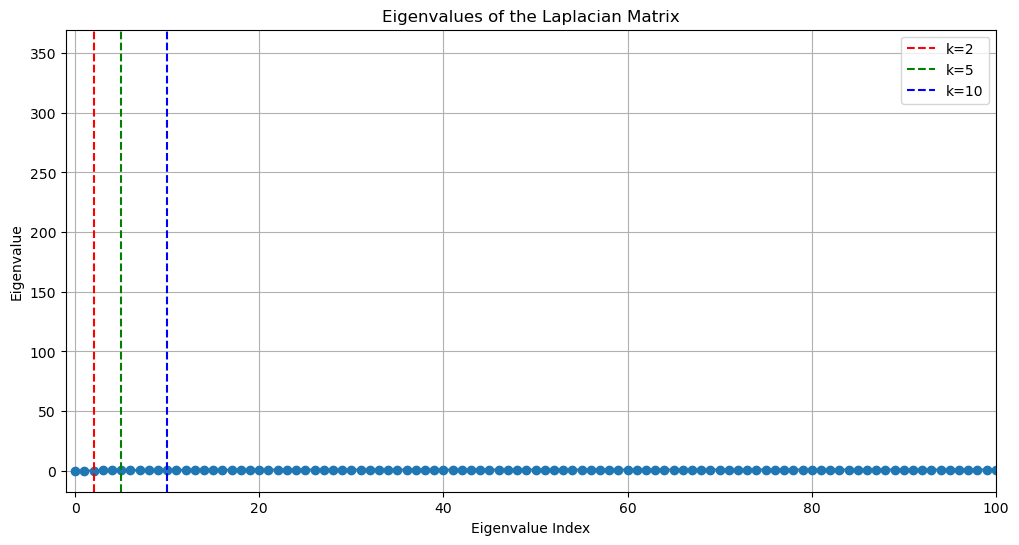

In [10]:
# Cell 10: Main Execution - Question 2: Tuning k - Eigenvalue Plot
print("\n--- Question 2: Tuning k ---")

# Plot eigenvalues to find a suitable k
laplacian = compute_laplacian(adj_matrix)
eigenvalues, _ = np.linalg.eigh(laplacian)
eigenvalues = np.sort(eigenvalues) # Ensure they are sorted

plt.figure(figsize=(12, 6))
plt.plot(range(len(eigenvalues)), eigenvalues, marker='o', linestyle='-')
plt.title('Eigenvalues of the Laplacian Matrix')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.xlim(-1, 100) # Focus on the smaller eigenvalues for better visualization of potential gaps
plt.axvline(x=2, color='r', linestyle='--', label='k=2')
plt.axvline(x=5, color='g', linestyle='--', label='k=5')
plt.axvline(x=10, color='b', linestyle='--', label='k=10')
plt.legend()
plt.show()


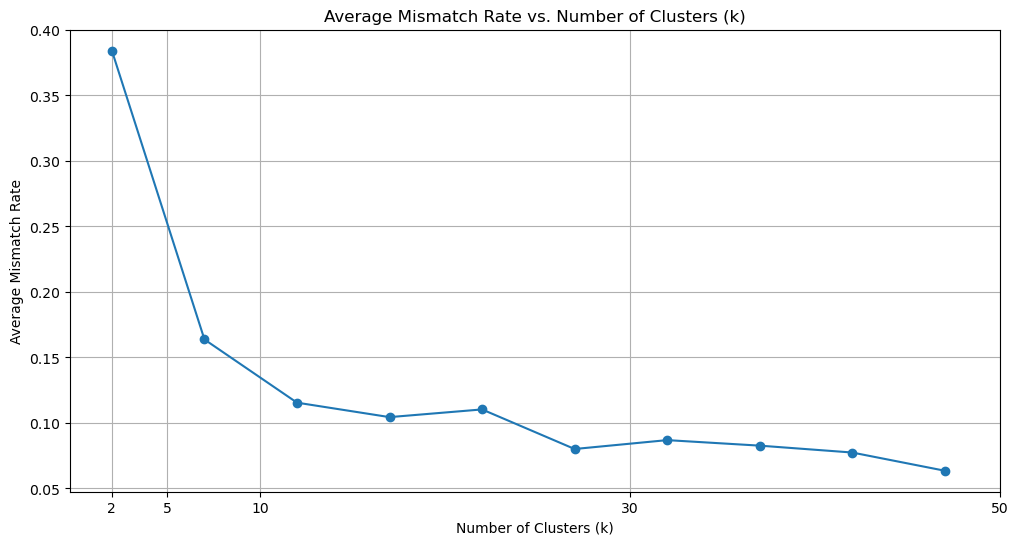


Optimal k found by minimizing average mismatch rate: 47
Achieved minimum average mismatch rate: 0.0635


In [11]:
# Cell 11: Main Execution - Question 2: Tuning k - Average Mismatch Rate Plot and Optimal k
# Re-run for a range of k values to find the best average mismatch rate
k_tuning_range = range(2, 51, 5) # Test k from 2 to 50
avg_mismatch_rates_tuning = []

for k_val in k_tuning_range:
    # Note: K-Means initialization is random, so results might vary slightly on each run.
    # For robust tuning, one might run spectral_clustering multiple times for each k_val and average.
    # For this exercise, a single run per k_val is sufficient as per the prompt.
    cluster_assignments_tuned = spectral_clustering(adj_matrix, k_val)
    mismatch_rates_tuned = calculate_mismatch_rate(cluster_assignments_tuned, node_labels, k_val)
    avg_mismatch_rates_tuning.append(np.mean(list(mismatch_rates_tuned.values())))

plt.figure(figsize=(12, 6))
plt.plot(k_tuning_range, avg_mismatch_rates_tuning, marker='o', linestyle='-')
plt.title('Average Mismatch Rate vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Mismatch Rate')
plt.grid(True)
plt.xticks(k_values) # Mark the specific k values from Q1 for reference
plt.show()

# Find the k with the minimum average mismatch rate
best_k = k_tuning_range[np.argmin(avg_mismatch_rates_tuning)]
min_mismatch_rate = np.min(avg_mismatch_rates_tuning)

print(f"\nOptimal k found by minimizing average mismatch rate: {best_k}")
print(f"Achieved minimum average mismatch rate: {min_mismatch_rate:.4f}")

In [12]:
# Optional: Display mismatch rates for the best_k if it wasn't already calculated in Q1
if best_k not in k_values:
    print(f"\nClustering for optimal k = {best_k} (if not already calculated):")
    cluster_assignments_best_k = spectral_clustering(adj_matrix, best_k)
    mismatch_rates_best_k = calculate_mismatch_rate(cluster_assignments_best_k, node_labels, best_k)
    for cluster_id, rate in mismatch_rates_best_k.items():
        print(f"  Cluster {cluster_id}: {rate:.4f}")


Clustering for optimal k = 47 (if not already calculated):
  Cluster 0: 0.2593
  Cluster 1: 0.0000
  Cluster 2: 0.0000
  Cluster 3: 0.0000
  Cluster 4: 0.0000
  Cluster 5: 0.0000
  Cluster 6: 0.1429
  Cluster 7: 0.0000
  Cluster 8: 0.0462
  Cluster 9: 0.0000
  Cluster 10: 0.0000
  Cluster 11: 0.0000
  Cluster 12: 0.0000
  Cluster 13: 0.0000
  Cluster 14: 0.4167
  Cluster 15: 0.0000
  Cluster 16: 0.0000
  Cluster 17: 0.0000
  Cluster 18: 0.4783
  Cluster 19: 0.0000
  Cluster 20: 0.1111
  Cluster 21: 0.0172
  Cluster 22: 0.0234
  Cluster 23: 0.0000
  Cluster 24: 0.0588
  Cluster 25: 0.0435
  Cluster 26: 0.0000
  Cluster 27: 0.0000
  Cluster 28: 0.0625
  Cluster 29: 0.0000
  Cluster 30: 0.1250
  Cluster 31: 0.2083
  Cluster 32: 0.0000
  Cluster 33: 0.4000
  Cluster 34: 0.0000
  Cluster 35: 0.0000
  Cluster 36: 0.0000
  Cluster 37: 0.0323
  Cluster 38: 0.0000
  Cluster 39: 0.0645
  Cluster 40: 0.1765
  Cluster 41: 0.1538
  Cluster 42: 0.0000
  Cluster 43: 0.1111
  Cluster 44: 0.0000
  Clu